## Track 2: Multi-Class Player Position Classification Pipeline

Predicting primary player position (`Goalkeeper`, `Defender`, `Midfielder`, `Forward`) based on performance and tactical metrics.


In [1]:
# Import analytical, classification, and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['figure.dpi'] = 120


## Section 1: Feature Selection & Data Preparation

We load the preprocessed classification dataset, select tactical features for predicting player positions, and split the data into 80% training and 20% testing sets using stratified sampling.


In [2]:
# Load preprocessed data
df_clf = pd.read_csv('../data/df_preprocessed_classification.csv')

# Feature selection: tactical performance metrics
clf_features = [
    'age', 'height_cm', 'weight_kg', 'minutes_played', 'goals', 'assists',
    'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
    'key_passes', 'pass_accuracy', 'tackles', 'interceptions', 'clearances',
    'blocks', 'recoveries', 'fouls_committed', 'distance_covered_km',
    'sprint_distance_km', 'top_speed_kmh', 'stamina_score', 'possession_impact',
    'creativity_score', 'consistency_score', 'pressure_resistance',
    'goal_contribution_rate', 'work_rate_intensity', 'passing_efficiency',
    'preferred_foot_Right'
]

X = df_clf[clf_features]
y = df_clf['position_encoded']

# Target class map
target_names = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']

# Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Preprocessed Dataset shape: {df_clf.shape}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


Preprocessed Dataset shape: (6000, 32)
X_train shape: (4800, 30), X_test shape: (1200, 30)


In [3]:
# Evaluation helper function
results_list = []

def evaluate_classifier(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    else:
        roc = np.nan
        
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model_obj': model
    })
    
    print(f"=== {name} Performance ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    return model


## Section 2: Core Classification Algorithms & Visual Insights

Evaluating 5 classification algorithms on multi-class position prediction, with specialized diagnostic plots for each model.


### 1. Logistic Regression
Logistic Regression is a linear baseline model that uses the softmax function to estimate class probabilities for multi-class classification.


=== Logistic Regression Performance ===
Accuracy : 0.8817
Precision: 0.8813
Recall   : 0.8817
F1-Score : 0.8815
ROC-AUC  : 0.9660


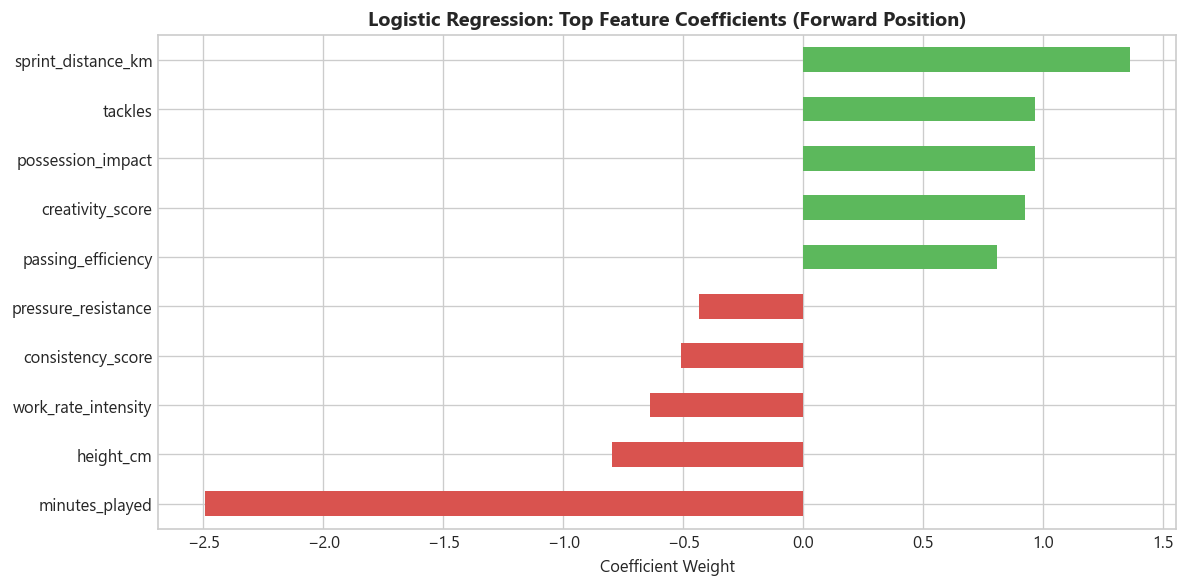

In [4]:
# 1. Logistic Regression: Model Training & Feature Coefficient Plot
lr_model = evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression',
    X_train, y_train, X_test, y_test
)

# Plot top feature coefficients for predicting Forward position vs others
plt.figure(figsize=(10, 5))
coef_df = pd.Series(lr_model.coef_[3], index=clf_features).sort_values()
top_coef = pd.concat([coef_df.head(5), coef_df.tail(5)])
top_coef.plot(kind='barh', color=['#d9534f' if x < 0 else '#5cb85c' for x in top_coef])
plt.title('Logistic Regression: Top Feature Coefficients (Forward Position)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Weight')
plt.tight_layout()
plt.show()


### 2. K-Nearest Neighbors Classifier
K-Nearest Neighbors classifies samples based on the majority vote of their k nearest neighbors in feature space.


=== K-Nearest Neighbors Performance ===
Accuracy : 0.8108
Precision: 0.8084
Recall   : 0.8108
F1-Score : 0.8089
ROC-AUC  : 0.9295


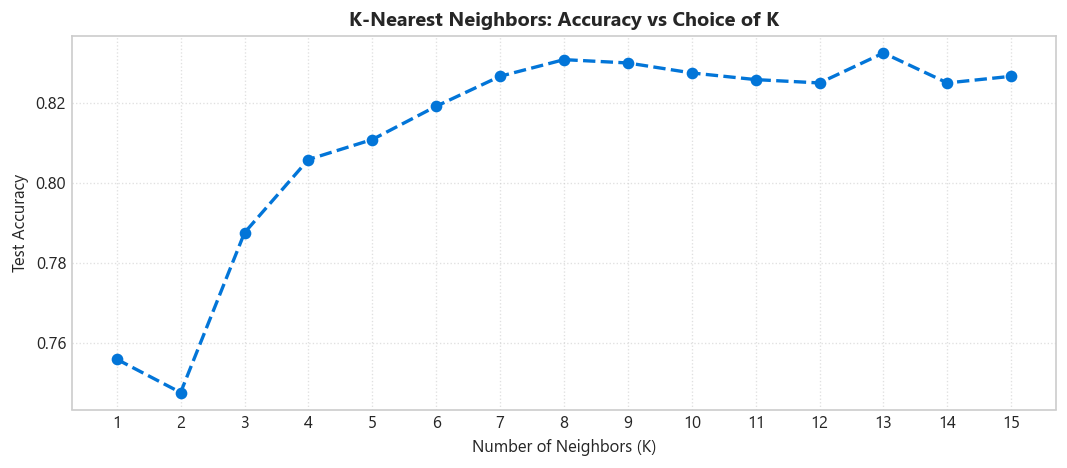

In [5]:
# 2. K-Nearest Neighbors: Model Training & K-Optimization Curve
knn_model = evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5),
    'K-Nearest Neighbors',
    X_train, y_train, X_test, y_test
)

# Plot K-Neighbors Accuracy Optimization Curve
k_values = list(range(1, 16))
k_scores = []
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    k_scores.append(knn_temp.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(k_values, k_scores, marker='o', linestyle='--', color='#0275d8', linewidth=2)
plt.title('K-Nearest Neighbors: Accuracy vs Choice of K', fontsize=12, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### 3. Gaussian Naive Bayes
Gaussian Naive Bayes applies Bayes theorem assuming conditional independence between features given the class label.


=== Gaussian Naive Bayes Performance ===
Accuracy : 0.7675
Precision: 0.7923
Recall   : 0.7675
F1-Score : 0.7708
ROC-AUC  : 0.9003


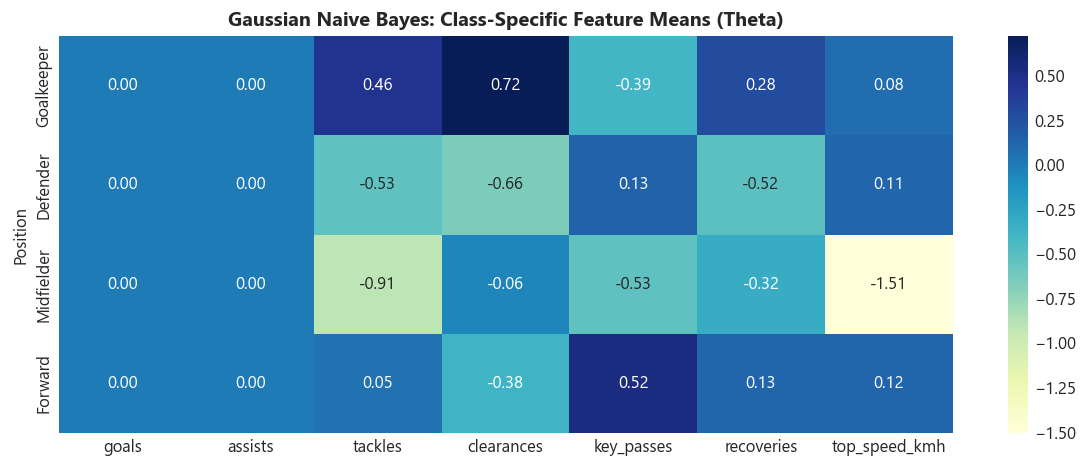

In [6]:
# 3. Gaussian Naive Bayes: Model Training & Feature Mean Profile Heatmap
nb_model = evaluate_classifier(
    GaussianNB(),
    'Gaussian Naive Bayes',
    X_train, y_train, X_test, y_test
)

# Plot heatmap of normalized feature means across player positions
theta_df = pd.DataFrame(nb_model.theta_, index=target_names, columns=clf_features)
selected_feats = ['goals', 'assists', 'tackles', 'clearances', 'key_passes', 'recoveries', 'top_speed_kmh']
plt.figure(figsize=(10, 4))
sns.heatmap(theta_df[selected_feats], annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Gaussian Naive Bayes: Class-Specific Feature Means (Theta)', fontsize=12, fontweight='bold')
plt.ylabel('Position')
plt.tight_layout()
plt.show()


### 4. Decision Tree Classifier
Decision Trees split data into hierarchical decision rules to maximize information gain and node purity.


=== Decision Tree Performance ===
Accuracy : 0.7167
Precision: 0.7164
Recall   : 0.7167
F1-Score : 0.7158
ROC-AUC  : 0.8743


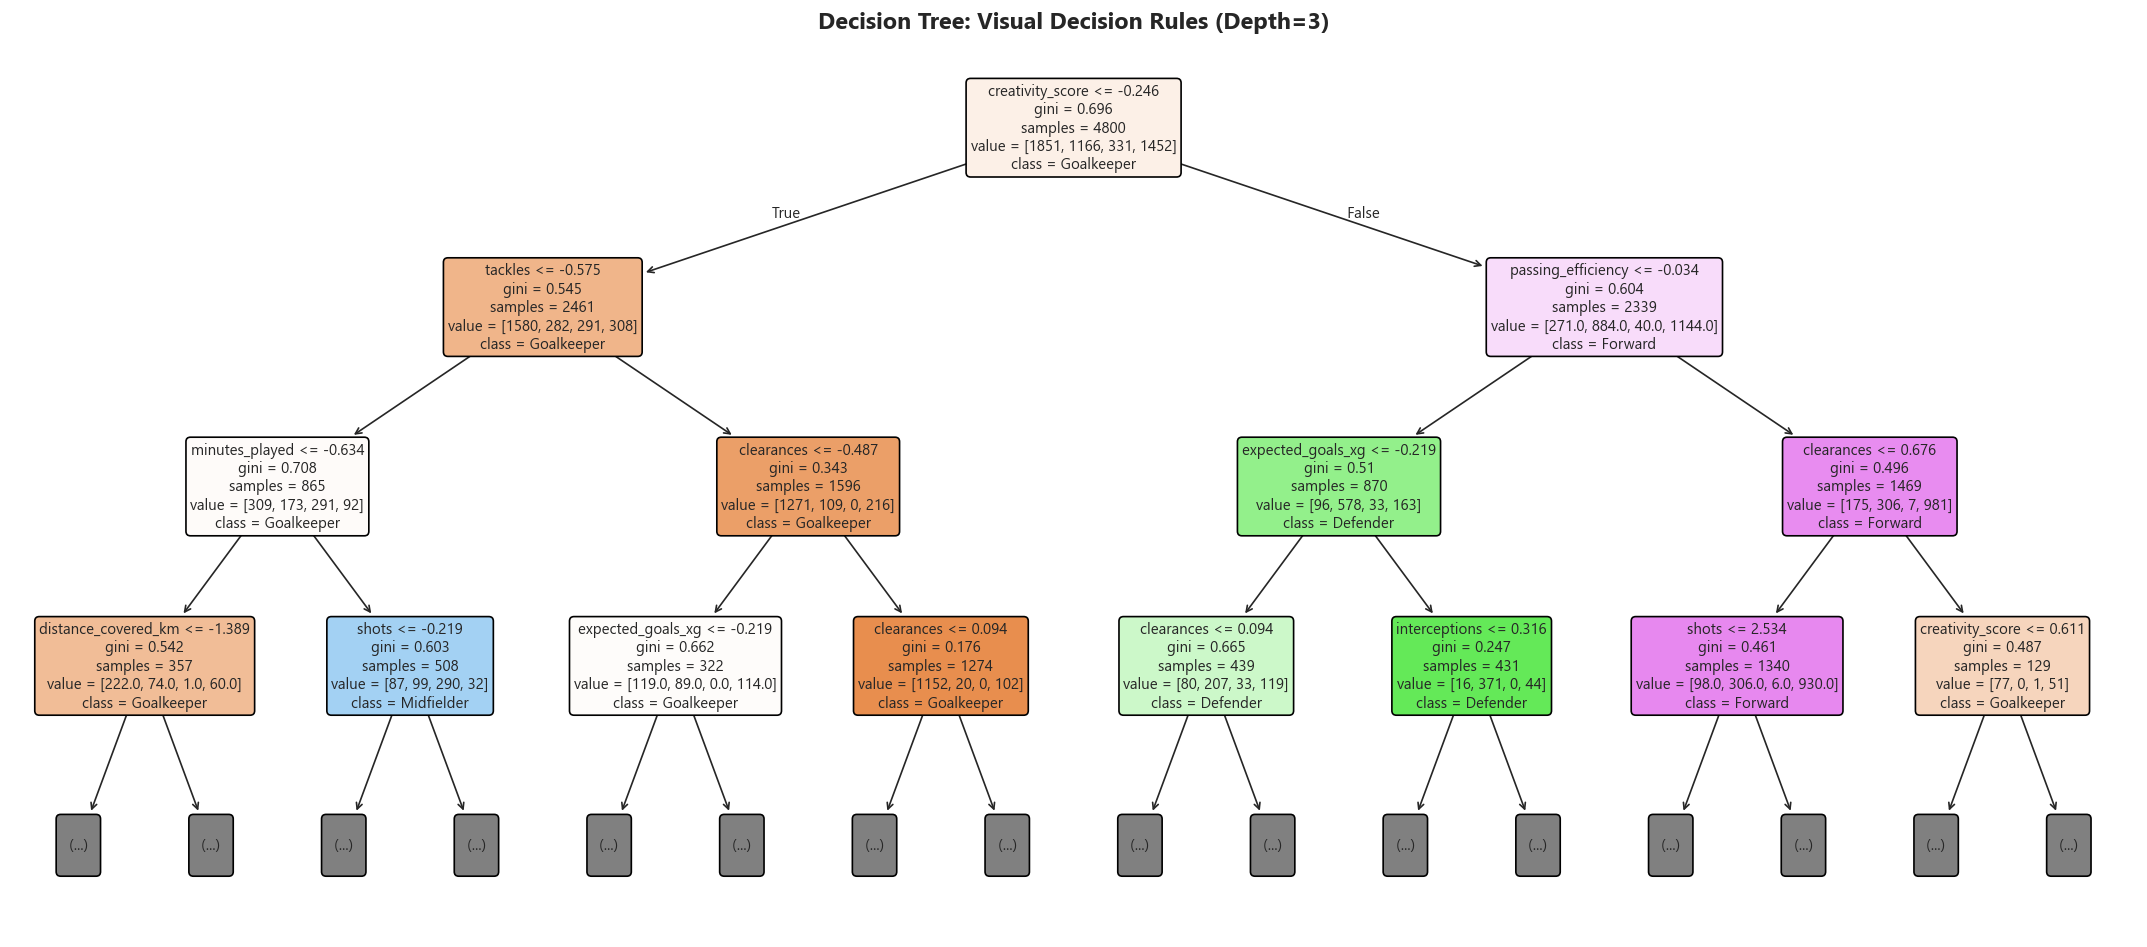

In [7]:
# 4. Decision Tree Classifier: Model Training & Visual Tree Structure
dt_model = evaluate_classifier(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    'Decision Tree',
    X_train, y_train, X_test, y_test
)

# Plot Visual Decision Tree Diagram
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=clf_features,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Decision Tree: Visual Decision Rules (Depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5. Support Vector Classifier (SVC)
Support Vector Classifier maximizes the margin between position classes using hyperplanes and kernel transformations.


=== Support Vector Machine Performance ===
Accuracy : 0.8767
Precision: 0.8769
Recall   : 0.8767
F1-Score : 0.8766
ROC-AUC  : 0.9675


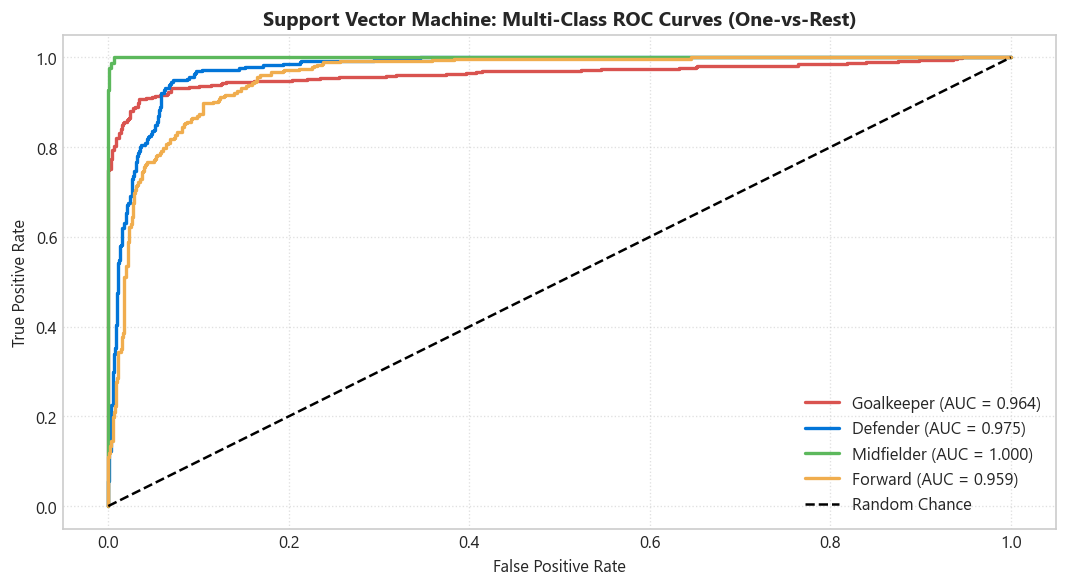

In [8]:
# 5. Support Vector Classifier (SVC): Model Training & Multi-Class ROC Curves
svc_model = evaluate_classifier(
    SVC(kernel='rbf', probability=True, random_state=42),
    'Support Vector Machine',
    X_train, y_train, X_test, y_test
)

# Plot Multi-Class ROC Curves for SVC
y_test_bin = pd.get_dummies(y_test).values
y_proba_svc = svc_model.predict_proba(X_test)

plt.figure(figsize=(9, 5))
colors = ['#d9534f', '#0275d8', '#5cb85c', '#f0ad4e']
for i, pos_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_svc[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_proba_svc[:, i])
    plt.plot(fpr, tpr, label=f'{pos_name} (AUC = {auc_val:.3f})', color=colors[i], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Support Vector Machine: Multi-Class ROC Curves (One-vs-Rest)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Section 3: Model Comparison & Confusion Matrix Analysis


In [9]:
# Construct Comparison Table
df_results = pd.DataFrame(results_list)
df_display = df_results[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].copy()
df_display = df_display.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print("=== Classification Model Comparison ===")
print(df_display.to_string(index=False))


=== Classification Model Comparison ===
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
   Logistic Regression  0.881667   0.881277 0.881667  0.881454 0.966042
Support Vector Machine  0.876667   0.876937 0.876667  0.876640 0.967490
   K-Nearest Neighbors  0.810833   0.808372 0.810833  0.808906 0.929502
  Gaussian Naive Bayes  0.767500   0.792347 0.767500  0.770832 0.900340
         Decision Tree  0.716667   0.716429 0.716667  0.715784 0.874257


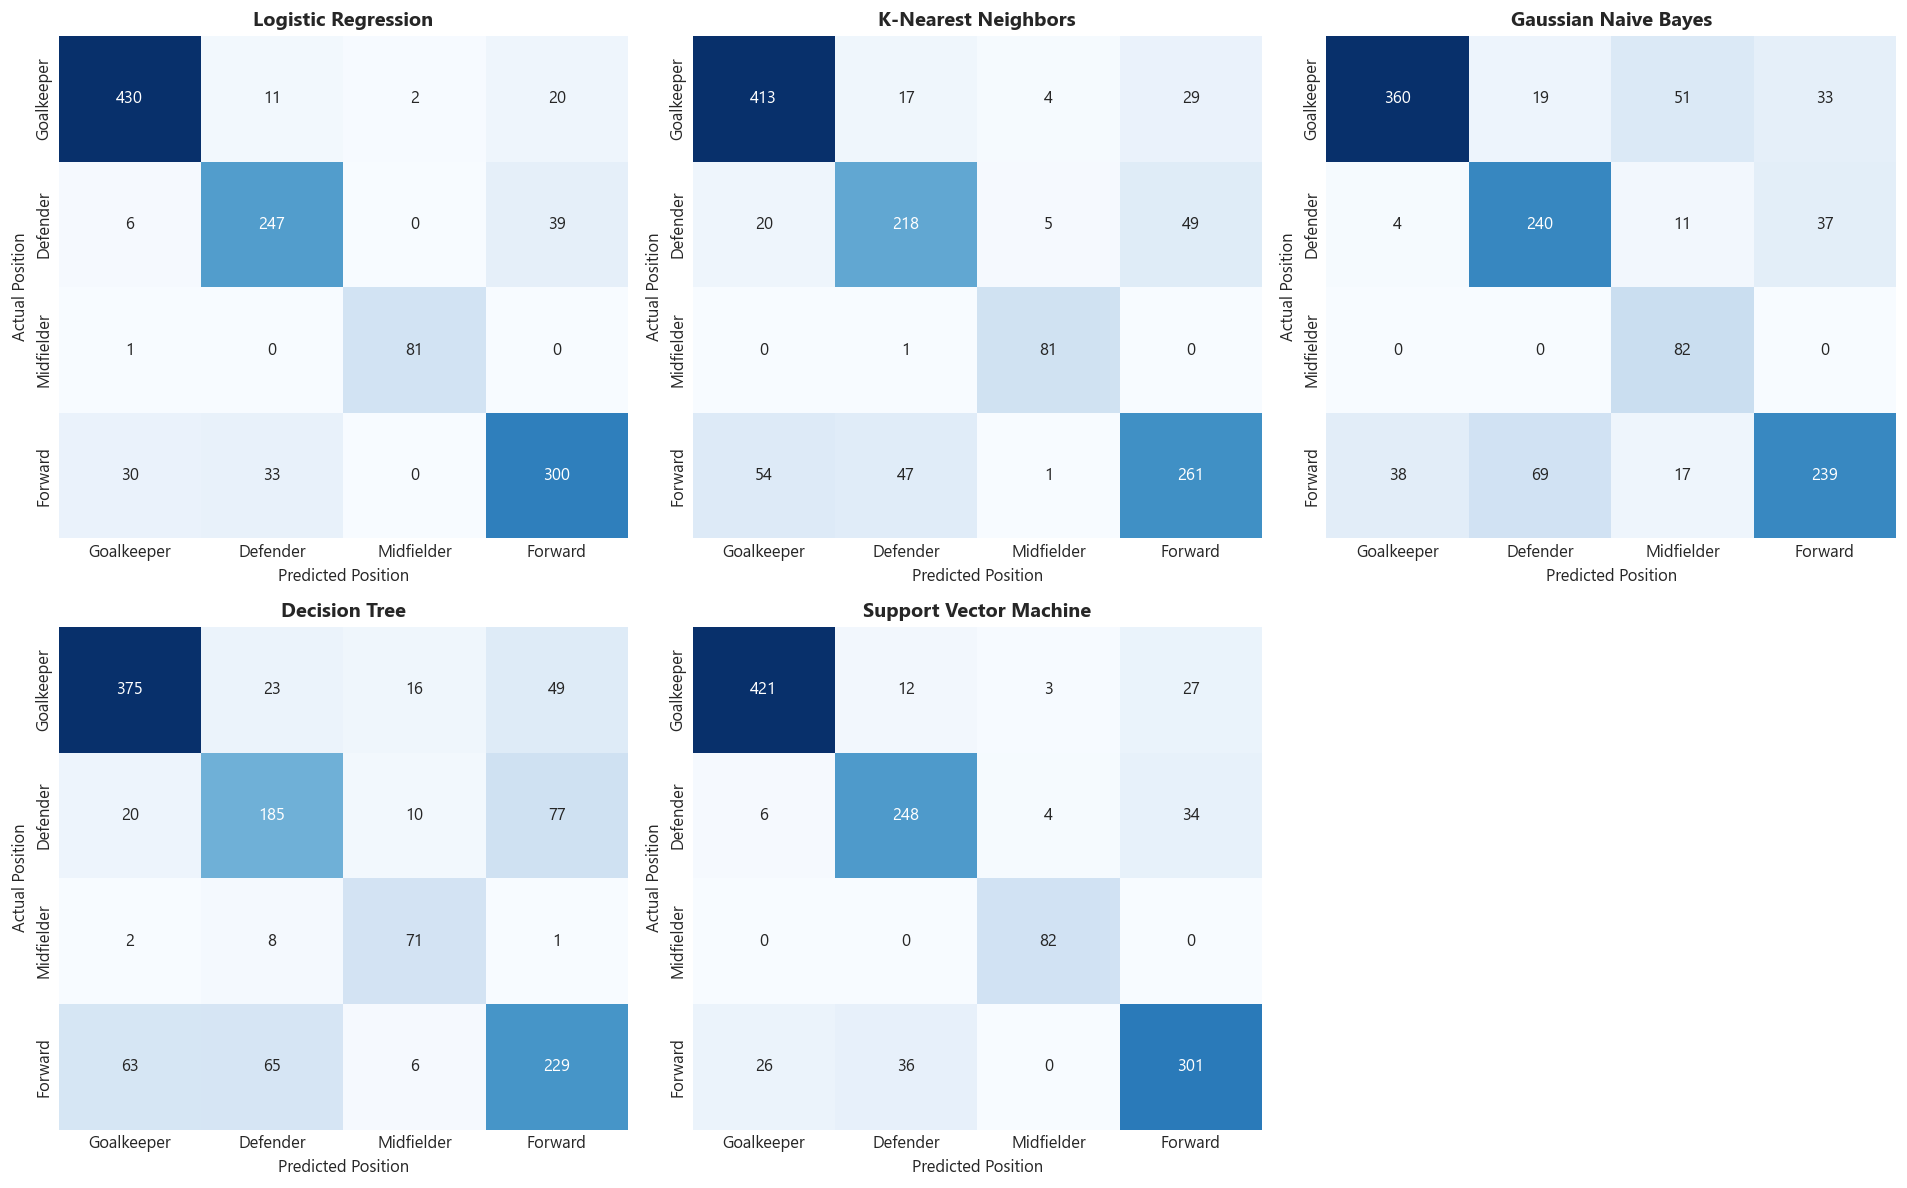

In [10]:
# Plot confusion matrices for all 5 models in 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, res in enumerate(results_list):
    ax = axes[i]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(res['Model'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Position', fontsize=10)
    ax.set_ylabel('Actual Position', fontsize=10)

# Hide unused 6th subplot frame
for j in range(len(results_list), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
